In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## deepCSA path

In [9]:
deepCSA_run_dir = "/data/bbg/nobackup/lung_duplex/analysis/fullcohortnormal/asxs10/2026-08-11_PEACE_TRACERx"

In [10]:
all_mutdensities = pd.read_table(f"{deepCSA_run_dir}/mutdensity/all_mutdensities.tsv", sep = "\t")

In [11]:
samples_and_mutdensity = all_mutdensities[(all_mutdensities["GENE"] == 'ALL_GENES')
                                            & (all_mutdensities["MUTTYPES"] == 'SNV')
                                            & (all_mutdensities["REGIONS"] == "all")
                                            ] [["SAMPLE_ID", "MUTDENSITY_MB"]]
samples_and_mutdensity

,SAMPLE_ID,MUTDENSITY_MB
19653,L883,0.297713
33629,L865,0.750569
34889,L935,0.488972
38461,SmokingstatusunifNever,0.263338
42033,L905,0.399045
...,...,...
893385,L393,0.497468
899269,L928,0.614416
900529,L394,0.436490
901789,L875,0.296914


In [12]:
samples_and_mutdensity[~(samples_and_mutdensity["SAMPLE_ID"].str.startswith("L"))].sort_values(by = "SAMPLE_ID", ascending = False)

,SAMPLE_ID,MUTDENSITY_MB
247337,all_samples,0.379713
201317,SmokingstatusunifUnknown,0.216706
38461,SmokingstatusunifNever,0.263338
817425,SmokingstatusunifFormer,0.444664
622421,SmokingstatusunifCurrent,0.536064
98353,CohortTracerx_SmokingstatusunifNever,0.281333
279589,CohortTracerx_SmokingstatusunifFormer,0.507360
718449,CohortTracerx_SmokingstatusunifCurrent,0.540464
739569,CohortTracerx_SexM,0.469281
596677,CohortTracerx_SexF,0.446257


## Load data and plot results

In [17]:
output_path = '/data/bbg/datasets/pipelines/deepCSA/files_for_exploration'

In [23]:
mutations_per_gene_consequence = pd.read_table(f"{output_path}/exome_lung_panel_genes_smokers.8x1000.mutations_per_gene_consequence.tsv",
                                               sep = "\t")
mutations_per_gene_consequence = mutations_per_gene_consequence.set_index(["GENE", "IMPACT"])
mutations_per_gene_consequence.head()

EXPECTED_MUTATIONS
GENE IMPACT                                   
ALK  essential_splice                  0.18797
     missense                          4.76482
     nonsense                          0.24592
     splice_region_variant             0.78864
     synonymous                        1.52028

In [24]:
consequences_to_plot = ['synonymous', 'missense', 'nonsense',
                        'essential_splice', 'splice_region_variant', 
                        # 'non_genic_variant',  'intron_variant',
                        # 'non_coding_exon_region', 'non_coding_transcript_variant'
                        ]

In [31]:
mutations_per_gene_consequence.unstack(level=0).loc[consequences_to_plot].columns.droplevel(0)

Index(['ALK', 'ARID1A', 'ARID2', 'ATM', 'BRAF', 'CDKN2A', 'CHEK2', 'CTNNB1',
       'EGFR', 'ERBB2', 'ERBB4', 'FAT1', 'KEAP1', 'KMT2D', 'KRAS', 'MAX',
       'NF1', 'NFE2L2', 'NOTCH1', 'PIK3CA', 'PTEN', 'RB1', 'RET', 'ROS1',
       'SETBP1', 'SETD2', 'SMAD4', 'SMARCA4', 'STK11', 'TIAM2', 'TP53'],
      dtype='object', name='GENE')

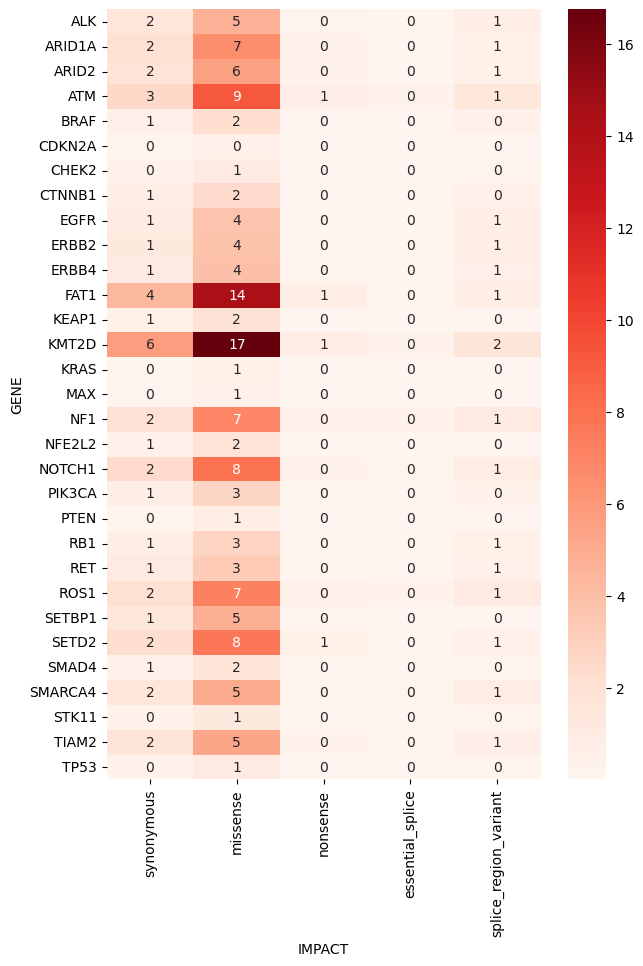

In [34]:
#plot mutations_per_gene_consequence as a heatmap
data_to_plot = mutations_per_gene_consequence.unstack(level=0).loc[consequences_to_plot]
data_to_plot.columns = data_to_plot.columns.droplevel(0)
data_to_plot = data_to_plot[[x for x in data_to_plot.columns if not data_to_plot[x].isna().all()]].T
plt.figure(figsize=(7, 10))
sns.heatmap(data_to_plot, annot=True, fmt=".0f", cmap="Reds")
plt.show()